In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib.colorbar as cbar
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection
import h5py
import os
from pathlib import Path
import pickle
from IPython.display import HTML
from cherab.tools.inversions import ToroidalVoxelGrid, invert_regularised_nnls
from cherab.core.math import sample2d
from voxels_sector_16 import get_value_at, interpolate_parameters, plot_interpolated
from matplotlib.colors import LogNorm
from matplotlib.colors import BoundaryNorm
from matplotlib.ticker import LogFormatter
from matplotlib.cm import inferno
import matplotlib.patches as patches

try:
    import aug_sfutils as sf
except:
    print("aug_sfutils not loaded")

plt.rcParams.update({'font.size': 16, "figure.dpi" : 150,
                     'figure.constrained_layout.use': True})

WORKDIR = "/tok/u/lefer/work/AUG-AXUV/AXUV/"
INPUTDIR = WORKDIR + "data/"
id_list = [
    "LF_FV_Ne0.12", 
    #"LF_FV_Ne1", 
    "LF_FV_Ne10", 
    "LF_HV_Ne10", 
    "SF_FV_Ne0.12", 
    "SF_FV_Ne10"
]
ID = "test_uniform"

CURRENTDIR = INPUTDIR + ID + "/"
PLOTDIR = CURRENTDIR + "plots_rt_highres/"
if not os.path.exists(PLOTDIR):
    os.mkdir(PLOTDIR)
OUTDIR = CURRENTDIR + "output/"
print(OUTDIR)
RAYTRANSFER_PATH = INPUTDIR + "raytransfer_S16_reflections_highres.h5"
PREFIX = "raytransfer_emissions_highres_1eV_"

AXUV_DATAFILE = INPUTDIR + "AXUV_LOS_geom.txt"
try:
    AXUV_DF = pd.read_csv(AXUV_DATAFILE, sep=r"\s+", engine='python').drop(columns=["act", "con", "F", "Foil_ID", 
                                                                                    "R_Kabel", "U_Gen.", "Faktor"])
except:
    print(AXUV_DATAFILE)
    print("Could not load AXUV geometry datafile")
    

# Load AXUV diode sensitivity data
sensitivity = np.genfromtxt(os.path.join(INPUTDIR, "axuv_sensitivity.csv"), delimiter=",")
degraded_sensitivity = np.genfromtxt(os.path.join(INPUTDIR, "degraded_sensitivity.csv"), delimiter=",")

jorekfilenames = sorted([f.name for f in Path(CURRENTDIR + "input/").iterdir() if (f.is_file() and "raytransfer" in str(f))])
filenames = sorted([f.name for f in Path(OUTDIR).iterdir() if (f.is_file() and PREFIX in str(f))])
times_SI = [float(f.removeprefix(PREFIX).removesuffix(".h5")) for f in filenames]
print(filenames)
print(len(filenames), " emission output files found.")

# If one has more fnames, the time evolution of the measurements can be visualized.
# The plots in this notebook are from one such case.

with open(INPUTDIR + "gc_d_lines.obj", "rb") as fp:
    # in a list of 2-element (R, z) lists of arrays 
    # for PFC visualization in the poloidal cross section
    gc_d_lines = pickle.load(fp)

# Voxel data handling
def open_voxel_measurements(fname, energy_cutoff=False):
    "Opens the emission data generated by calculate_emissions_for_raytransfer.py and returns everything from the file."
    with h5py.File(OUTDIR + fname, "r") as file:
        emissions = file["emissions"][()]
        wavelengths = file["wavelengths"][()]
        energies = file["energies"][()]
        diode_measurements = file["diode_measurements"][()]
    if not energy_cutoff:
        return wavelengths, energies, emissions, diode_measurements
    else:
        return wavelengths, energies[:-1], emissions, diode_measurements

def load_voxels(name=RAYTRANSFER_PATH):
    """Loads and returns relevant raytransfer data from HDF5"""
    try:
        with h5py.File(RAYTRANSFER_PATH, 'r') as h5f:
            sensitivity_matrix = h5f["sensitivity_matrix"][()]
            grid_centres = h5f["grid_centres"][()]
            voxel_map = h5f["voxel_map"][()]
            inverse_voxel_map = h5f["inverse_voxel_map"][()]
            laplacian = h5f["laplacian"][()]
            mask = h5f["mask"][()]
            completed_bins = h5f["completed_bins"][()]
        print("Sensitivity matrix loaded")
    except:
        print("Sensitivity matrix file not found!")
    print("Raytransfer data loaded.")
    
    return grid_centres, voxel_map, inverse_voxel_map, sensitivity_matrix

# Setting up AXUV sensitivity functions from the sensitivity data
def sensitivity_function(where):
    """
    Manufacturer specified sensitivity function of the AXUV diodes in A/W 

    :param float where: where to sample the sensitivity function in energy [eV]
    """
    return np.interp(where, sensitivity[:, 0], sensitivity[:, 1])

def degraded_sensitivity_function(where):
    """
    Average degraded sensitivity function of the AXUV diodes in A/W 
    from [M. Bernert, Rev. Sci. Instrum., 2014] 

    :param where: where to sample the sensitivity function in energy [eV]
      Can be a list or numpy array or can be float or int
    """
    if isinstance(where, (list, np.ndarray)):
        toreturn = np.zeros(len(where))
        for index, loc in enumerate(where):
            if loc < 89.4308:
                toreturn[index] = np.interp(loc, sensitivity[:, 0], sensitivity[:, 1])
            else:
                toreturn[index] = np.interp(loc, degraded_sensitivity[:, 0], degraded_sensitivity[:, 1])
        return toreturn
    elif isinstance(where, (float, int)):
        if where < 89.4308:
            return np.interp(where, sensitivity[:, 0], sensitivity[:, 1])
        else:
            return np.interp(where, degraded_sensitivity[:, 0], degraded_sensitivity[:, 1])
    else:
        print("Unsupported type passed to degraded_sensitivity_function()")

# static plotting    
def plot_voxel_data(ax, voxels, voxel_values, cmap="inferno", vmin=None, vmax=None, title=None, limits=None,
                    norm="linear", plot_LOS=False, axuv_df=AXUV_DF, linec="k"):
    """
    Either only plot the voxel locations if voxel_values is None
    or color the voxels according to voxel_values.
    Useful for plotting emissions and optionally inversions.
    """ 
    patches = []
    for voxel in voxels:
        polygon = Polygon([(v.x, v.y) for v in voxel.vertices], closed=True)
        patches.append(polygon)

    p = PatchCollection(patches, cmap=cmap, norm=norm)
    if voxel_values is None:
        # Plot just the outlines of the grid cells
        p.set_edgecolor('black')
        p.set_facecolor('none')
    else:
        p.set_array(voxel_values)
        vmax = vmax or max(voxel_values)
        if vmin is not None and vmin < 0:
            vmin = 10 ** (np.log10(vmax) + vmin)
        elif vmin is not None and vmin > 0:
            pass
        else:
            vmin = min(voxel_values)
        p.set_clim([vmin, vmax])

    if ax is None:
        _, ax = plt.subplots()

    ax.add_collection(p)
    ax.axis("equal")

    if plot_LOS:
        df_0 = axuv_df[axuv_df['Cam'].str.contains("DHT", na=False)]
        df_1 = axuv_df[axuv_df['Cam'].str.contains("D16", na=False)]

        R1 = df_0['R_start'][:5]
        R2 = df_0['R_end'][:5]
        z1 = df_0['z_start'][:5]
        z2 = df_0['z_end'][:5]
        ax.plot([R1, R2], [z1, z2], ls="-.", c=linec, lw=.5)

        # R1 = df_1['R_start']
        # R2 = df_1['R_end']
        # z1 = df_1['z_start']
        # z2 = df_1['z_end']
        # ax.plot([R1, R2], [z1, z2], ls="-.", c=linec, lw=.5)

    if limits is None:
        ax.set_xlim(voxels.min_radius, voxels.max_radius)
        ax.set_ylim(voxels.min_height, voxels.max_height)
    else:
        ax.set_xlim(limits[0], limits[1])
        ax.set_ylim(limits[2], limits[3])

    ax.set_xlabel("R [m]")
    ax.set_ylabel("z [m]")
    plt.colorbar(p, ax=ax)
    
    if title is not None:
        ax.set_title(title)
    return ax

# Animation
def plot_init():
    """Initialization function for animating two subfigures"""
    fig = plt.figure(figsize=(4, 8))
    gs = fig.add_gridspec(3, 1, height_ratios=[3.9, 0.1, 1])

    # Create two axes
    ax1 = fig.add_subplot(gs[0])
    ax2 = fig.add_subplot(gs[2])

    axlist = [ax1, ax2]
    return fig, axlist

def plot_voxel_radiation(index, axlist, emission_data):
    """
    The function called in each step of the animation function
    Plots emission data in the poloidal cross section from one spectral bin.
    Shows the actual spectral bin with red lines overlayed 
    on the sensitivity function plotted in energy
    """
    print(index, end="\r")
    ax1, ax2 = axlist
    ax1.clear()
    ax2.clear()
    plot_voxel_data(ax=ax1, voxels=voxel_grid, 
                    voxel_values=np.sum(emission_data[10*index:10*index+10, :],
                                        axis=0), title="Emitted radiation by the"
                                        "\nvoxels in one spectral bin")

    ax1.set_facecolor('k')
    for line in gc_d_lines:
        ax1.plot(line[0], line[1], lw=.5, c="white")
    ax1.set_xlim(1, 2.2)
    ax1.set_ylim(-1.2, 1)
    ax1.set_xlabel('R')
    ax1.set_ylabel('z')

    ax2.plot(energies, sensitivity_function(energies))
    ax2.axvline(energies[10*index], color="red")
    ax2.axvline(energies[10*index+10], color="red")
    ax2.set_xscale("log")
    ax2.set_xlim(0.9, 5000)
    ax2.grid()
    ax2.set_title("Spectral responsivity")
    ax2.set_xlabel("Photon energy [eV]")
    
    axlist2 = [ax1, ax2]
    return axlist2

def animate_voxel_emissions(fname):
    """
    This function is the main animation handler, and the reason this script is in a notebook
    One can set this up so that the video is saved with the help of the animation writer in the commented line
    """
    fig, axlist = plot_init()
    print(len(axlist))
    _, _, emissions, _, _, _ = open_voxel_measurements(fname)

    ani = animation.FuncAnimation(fig, plot_voxel_radiation, init_func=plot_init, 
                                frames=range(29), interval=500, blit=False, fargs=(axlist, emissions))
    # writervideo = animation.FFMpegWriter(fps=5)
    video = ani.to_html5_video()

    return video

# Get the synthetic measurements by applying the spectral sensitivity of the diodes
def get_weighted_power(diode_data, spectrum_energies, degraded=0):
    """
    Spectrally scales the power detected by the AXUV diodes with either the manufacturer-specified
    spectral response function (degraded=0) or with the degraded response function (degraded=1).
    Use the energies array returned by open_voxel_measurements() for :param spectrum_energies:
    """
    weighted_power = np.zeros(diode_data.shape[0])
    for i, energy in enumerate(spectrum_energies):
        try:
            dE_1 = np.abs(energy - spectrum_energies[i-1]) / 2
        except IndexError:
            dE_1 = np.abs(energy - spectrum_energies[i+1]) / 2

        try:
            dE_2 = np.abs(energy - spectrum_energies[i+1]) / 2
        except IndexError:
            dE_2 = np.abs(energy - spectrum_energies[i-1]) / 2

        # since spectrum_energies is decreasing in energy:
        averaging_range = np.linspace(energy+dE_1, energy-dE_2, 100)

        if degraded == 1:
            average_weight = np.average(degraded_sensitivity_function(averaging_range))
        elif degraded == 0:
            average_weight = np.average(sensitivity_function(averaging_range))

        weighted_power[:] += diode_data[:, i] * average_weight

    return weighted_power

def weigh_emission_by_spectral_response(emissions, spectrum_energies, degraded=0):
    weighted_emissions = np.zeros(emissions.shape[1])
    for i, energy in enumerate(spectrum_energies):
        try:
            dE_1 = np.abs(energy - spectrum_energies[i-1]) / 2
        except IndexError:
            dE_1 = np.abs(energy - spectrum_energies[i+1]) / 2

        try:
            dE_2 = np.abs(energy - spectrum_energies[i+1]) / 2
        except IndexError:
            dE_2 = np.abs(energy - spectrum_energies[i-1]) / 2

        # since spectrum_energies is decreasing in energy:
        averaging_range = np.linspace(energy+dE_1, energy-dE_2, 100)

        if degraded == 1:
            average_weight = np.average(degraded_sensitivity_function(averaging_range))
        elif degraded == 0:
            average_weight = np.average(sensitivity_function(averaging_range))

        weighted_emissions[:] += emissions[i, :] * average_weight

    return weighted_emissions

# Visualize the time evolution of a range of diode measurements
def time_evolution(diode_first, diode_last, filenames, noise=False, degraded=0, plot=True):
    """
    Plots the time evolution of the synthetic measurement AXUV diode signals with log normalization.
    Returns the figure, the axis, the pcolormesh object, and the data in a 2D array (diodes by time).
    The user may add Gaussian noise with FWHM=10%
    Either uses the manufacturer specified or the degraded spectral response function.

    NOTE that the user has to specify the first and the last diodes to display,
    for this they have to be familiar with the emission output file or how it was created.
    The diodes are appended after each other
    in the order depending on how the cameras have been specified:
    ```
    for camera in cameras:
        for diode in camera.foil_detectors:
            diodename_list.append(diode.name)
    ```
    Otherwise HDFView or the h5py Python library can help to look inside the file.
    """
    times = np.array([float(s.removeprefix(PREFIX).removesuffix(".h5")) for s in filenames])
    numofdiodes = diode_last-diode_first
    diode_data_evolution = np.zeros([numofdiodes, len(filenames)])
    if noise:
        noise_array = np.random.normal(1.0, 0.1, numofdiodes)
    for i, fname in enumerate(filenames):
        wavelengths, energies, emissions, diode_measurements = open_voxel_measurements(fname, energy_cutoff=True)
        diode_data = diode_measurements[diode_first:diode_last]
        diode_data_evolution[:, i] = get_weighted_power(diode_data, energies, degraded=degraded)
        if noise:
            diode_data_evolution[:, i] *= noise_array

    if plot:
        fig, ax = plt.subplots(figsize=(8,4.5))
        pcm = ax.pcolormesh(times*1e3, range(numofdiodes), diode_data_evolution, norm="log", vmin=1e-5, cmap="inferno")
        return fig, ax, pcm, diode_data_evolution
    else:
        return diode_data_evolution

grid_centres, voxel_map, inverse_voxel_map, sensitivity_matrix = load_voxels(name=RAYTRANSFER_PATH)

wavelengths, energies, emissions, diode_measurements = open_voxel_measurements(filenames[0], energy_cutoff=False)
print(energies.shape)
# diode order: first DHT 1 - 48, then D16 1 - 48


aug_sfutils not loaded
/tok/u/lefer/work/AUG-AXUV/AXUV/data/test_uniform/output/
['raytransfer_emissions_highres_1eV_0.0005.h5', 'raytransfer_emissions_highres_1eV_0.000600.h5']
2  emission output files found.
Sensitivity matrix loaded
Raytransfer data loaded.
(298,)


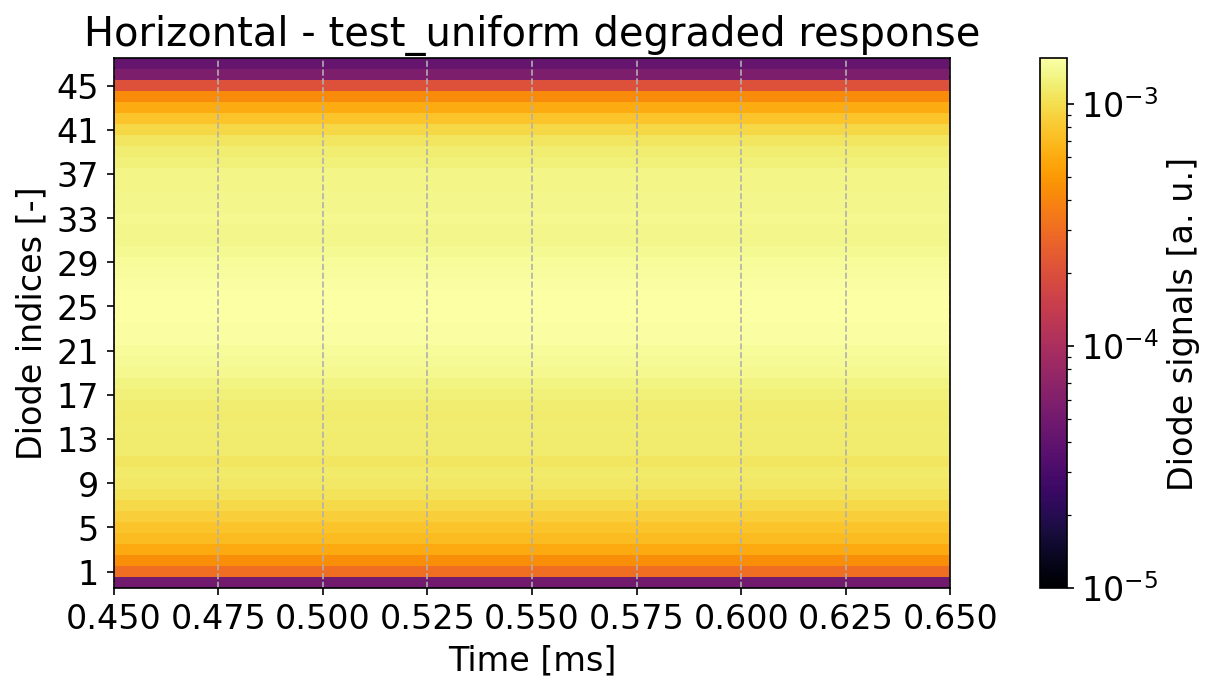

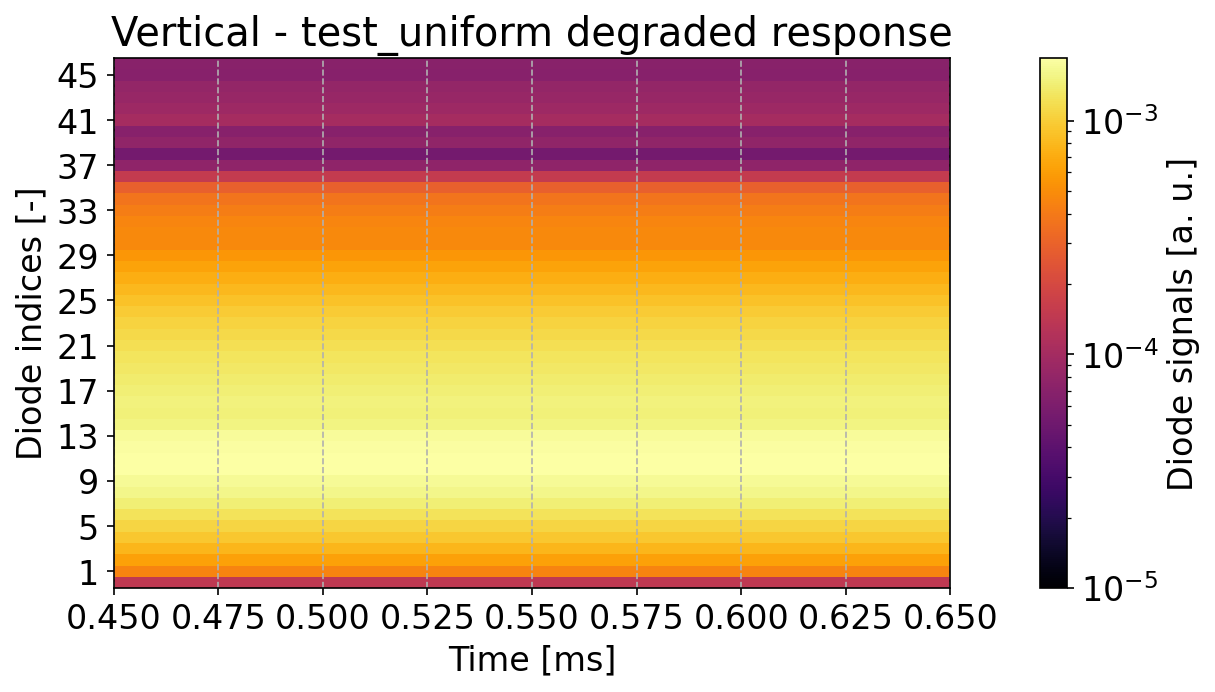

In [7]:
title_end = ID + " degraded response"
degradation = 1

tickrange = np.arange(1, 49, 4)
fig, ax, pcm, diode_data_evolution = time_evolution(0, 48, filenames, noise=False, degraded=degradation)
ax.xaxis.grid(True, linestyle='--', zorder=5)
ax.set_facecolor("k")
ax.set_xlim(None, None)
ax.set_xlabel("Time [ms]")
ax.set_ylabel("Diode indices [-]")
ax.set_title("Horizontal - " + title_end)
plt.yticks(tickrange)
cbar = plt.colorbar(pcm)
cbar.set_label('Diode signals [a. u.]')
plt.savefig(PLOTDIR+"_horiz_degr.png")
plt.show()

fig, ax, pcm, diode_data_evolution = time_evolution(49, 96, filenames, noise=False, degraded=degradation)
ax.xaxis.grid(True, linestyle='--', zorder=5)
ax.set_facecolor("k")
ax.set_xlim(None, None)
ax.set_xlabel("Time [ms]")
ax.set_ylabel("Diode indices [-]")
ax.set_title("Vertical - " + title_end)
plt.yticks(tickrange)
cbar = plt.colorbar(pcm)
cbar.set_label('Diode signals [a. u.]')
plt.savefig(PLOTDIR+"_vert_degr.png")
plt.show()

In [5]:
resolution_R = 120
resolution_z = 220

# geometry limits in the poloidal cross section
POLOIDAL_RMIN = 1
POLOIDAL_RMAX = 2.2
POLOIDAL_ZMIN = -1.2
POLOIDAL_ZMAX = 1

dx = np.round((POLOIDAL_RMAX - POLOIDAL_RMIN) / resolution_R, 2) * 1.05
dy = np.round((POLOIDAL_ZMAX - POLOIDAL_ZMIN) / resolution_z, 2) * 1.05
print(dx, dy)

NUM_OF_BINS = wavelengths.shape[0] - 1

cmap = plt.cm.inferno

for k in range(len(filenames)):
    fig, ax = plt.subplots(figsize=(4, 5))
    _, _, emissions, _ = open_voxel_measurements(filenames[k], energy_cutoff=False)
    values = emissions.sum(axis=1)
    norm = LogNorm(vmin=1, vmax=1e8)
    
    for i in range(inverse_voxel_map.shape[0]):
        # Get the indices of the i-th voxel in the grid_centres array
        aa = inverse_voxel_map[i, 0, 0]
        cc = inverse_voxel_map[i, 2, 0]

        # Get the real world coordinates corresponding to the i-th voxel
        xi = np.round(grid_centres[aa, cc, 0], 3)  # To get R coordinate
        yi = np.round(grid_centres[aa, cc, 1], 3)  # To get z coordinate

        val = np.sum(emissions[i, :])
        color = cmap(norm(val))
        rect = patches.Rectangle(
            (xi - dx/2, yi - dy/2),  # bottom-left corner
            dx, dy,
            facecolor=color,
            edgecolor='none'
        )
        ax.add_patch(rect)
    
    for line in gc_d_lines:
        ax.plot(line[0], line[1], lw=.5, c="grey", zorder=50)
    
    ax.set_xlabel("r")
    ax.set_ylabel("z")
    ax.set_facecolor('k')
    ax.set_aspect(1.0)
    plt.xlim(POLOIDAL_RMIN-0.1, POLOIDAL_RMAX+0.1)
    plt.ylim(POLOIDAL_ZMIN-0.1, POLOIDAL_ZMAX+0.1)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax)
    cbar.set_label("Emission density [W/m^3]")
    
    plt.title(str(np.round(times_SI[k] * 1000, 2))+" ms")
    plt.savefig(PLOTDIR + "emissions_" + str(k) + ".png", dpi=150)
    print(k)
    plt.close()

0.0105 0.0105
0
1


In [9]:
RAYTRANSFER_PATH = INPUTDIR + "raytransfer_S16_reflections_lowres.h5"
PREFIX = "raytransfer_emissions_lowres_1eV_"

for ID in id_list:
    try: 
        CURRENTDIR = INPUTDIR + ID + "/"
        PLOTDIR = CURRENTDIR + "plots_rt_lowres/"
        if not os.path.exists(PLOTDIR):
            os.mkdir(PLOTDIR)
        OUTDIR = CURRENTDIR + "output/"
        print(OUTDIR)

        jorekfilenames = sorted([f.name for f in Path(CURRENTDIR + "input/").iterdir() if (f.is_file() and "raytransfer" in str(f))])
        filenames = sorted([f.name for f in Path(OUTDIR).iterdir() if (f.is_file() and PREFIX in str(f))])
        times_SI = [float(f.removeprefix(PREFIX).removesuffix(".h5")) for f in filenames]
        print(len(filenames), " emission output files found.")

        # path = "/u/lefer/shares_AUG/AXUV/data_export/raytransfer/"
        path = PLOTDIR

        title_end = ID + " degraded response"
        degradation = 1

        tickrange = np.arange(1, 49, 4)
        fig, ax, pcm, diode_data_evolution = time_evolution(0, 48, filenames, noise=False, degraded=degradation)
        ax.xaxis.grid(True, linestyle='--', zorder=5)
        ax.set_facecolor("k")
        ax.set_xlim(None, None)
        ax.set_xlabel("Time [ms]")
        ax.set_ylabel("Diode indices [-]")
        ax.set_title("Horizontal - " + title_end)
        plt.yticks(tickrange)
        cbar = plt.colorbar(pcm)
        cbar.set_label('Diode signals [a. u.]')
        plt.savefig(path+ID+"_horiz_degr.png")
        plt.close()

        fig, ax, pcm, diode_data_evolution = time_evolution(49, 96, filenames, noise=False, degraded=degradation)
        ax.xaxis.grid(True, linestyle='--', zorder=5)
        ax.set_facecolor("k")
        ax.set_xlim(None, None)
        ax.set_xlabel("Time [ms]")
        ax.set_ylabel("Diode indices [-]")
        ax.set_title("Vertical - " + title_end)
        plt.yticks(tickrange)
        cbar = plt.colorbar(pcm)
        cbar.set_label('Diode signals [a. u.]')
        plt.savefig(path+ID+"_vert_degr.png")
        plt.close()

        title_end = ID + " manufact. response"
        degradation = 0
        tickrange = np.arange(1, 49, 4)
        fig, ax, pcm, diode_data_evolution = time_evolution(0, 48, filenames, noise=False, degraded=degradation)
        ax.xaxis.grid(True, linestyle='--', zorder=5)
        ax.set_facecolor("k")
        ax.set_xlim(None, None)
        ax.set_xlabel("Time [ms]")
        ax.set_ylabel("Diode indices [-]")
        ax.set_title("Horizontal - " + title_end)
        plt.yticks(tickrange)
        cbar = plt.colorbar(pcm)
        cbar.set_label('Diode signals [a. u.]')
        plt.savefig(path+ID+"_horiz.png")
        plt.close()

        fig, ax, pcm, diode_data_evolution = time_evolution(49, 96, filenames, noise=False, degraded=degradation)
        ax.xaxis.grid(True, linestyle='--', zorder=5)
        ax.set_facecolor("k")
        ax.set_xlim(None, None)
        ax.set_xlabel("Time [ms]")
        ax.set_ylabel("Diode indices [-]")
        ax.set_title("Vertical - " + title_end)
        plt.yticks(tickrange)
        cbar = plt.colorbar(pcm)
        cbar.set_label('Diode signals [a. u.]')
        plt.savefig(path+ID+"_vert.png")
        plt.close()
    
    except:
        print(ID+" ERROR")

/tok/u/lefer/work/AUG-AXUV/AXUV/data/LF_FV_Ne0.12/output/
25  emission output files found.
/tok/u/lefer/work/AUG-AXUV/AXUV/data/LF_FV_Ne10/output/
28  emission output files found.
/tok/u/lefer/work/AUG-AXUV/AXUV/data/LF_HV_Ne10/output/
21  emission output files found.
/tok/u/lefer/work/AUG-AXUV/AXUV/data/SF_FV_Ne0.12/output/
25  emission output files found.
/tok/u/lefer/work/AUG-AXUV/AXUV/data/SF_FV_Ne10/output/
17  emission output files found.


In [22]:
ID = id_list[2]
CURRENTDIR = INPUTDIR + ID + "/"
PLOTDIR = CURRENTDIR + "plots_rt/"
if not os.path.exists(PLOTDIR):
    os.mkdir(PLOTDIR)
OUTDIR = CURRENTDIR + "output/"
print(OUTDIR)

jorekfilenames = sorted([f.name for f in Path(CURRENTDIR + "input/").iterdir() if (f.is_file() and "raytransfer" in str(f))])
filenames = sorted([f.name for f in Path(OUTDIR).iterdir() if (f.is_file() and "raytransfer" in str(f))])
times_SI = [float(f.removeprefix(PREFIX).removesuffix(".h5")) for f in filenames]
print(len(filenames), "emission output files found.")


/tok/u/lefer/work/AUG-AXUV/AXUV/data/LF_FV_Ne10/output/
28 emission output files found.


In [ ]:

diode_data_evolution = time_evolution(0, 48, filenames, noise=False, degraded=1, plot=False)

diodes = np.arange(1, 49)
tickrange = np.arange(1, 49, 2)
plt.figure( figsize=[8,5])
for i in range(5):
    plt.step(diodes, diode_data_evolution[:, i], label="{} ms".format(times_SI[i]*1000), where="mid")

plt.yscale("log")
plt.xticks(tickrange)
plt.grid(which="minor")
plt.grid(which="major")
plt.ylim(1e-4, None)
plt.legend()
plt.title("LF_FV_Ne10")
plt.xlabel("DHT diode numbers [-]")
plt.ylabel("Diode signals [a. u.]")

plt.show()
# 1st timestep 10% horizontal camera

In [23]:
emissions.shape

(5195, 297)

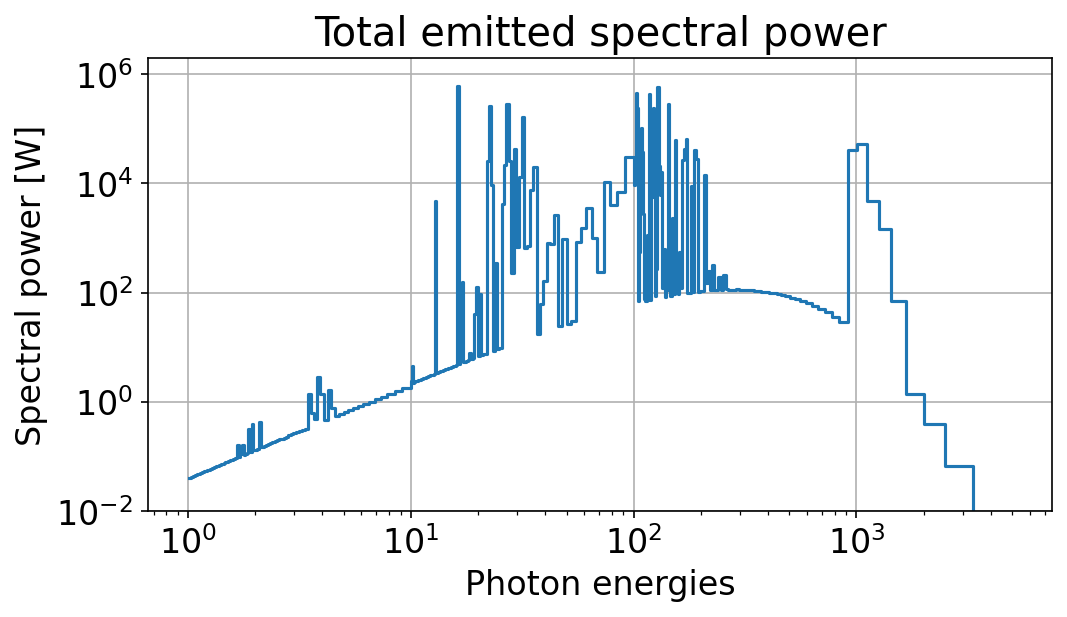

In [20]:
# Total emitted spectral power in the poloidal cross-section - raytransfer - w/ reflections
plt.figure(figsize=(7,4))
plt.step(energies, np.sum(emissions, axis=0)*0.02**2)
plt.yscale("log")
plt.xscale("log")
plt.ylim(1e-2, None)
plt.xlabel("Photon energies")
plt.ylabel(r"Spectral power [W]")
plt.title("Total emitted spectral power")
plt.grid()
plt.show()

0.0105 0.0105
/tok/u/lefer/work/AUG-AXUV/AXUV/data/LF_FV_Ne0.12/output/
25 emission output files found.


KeyboardInterrupt: 

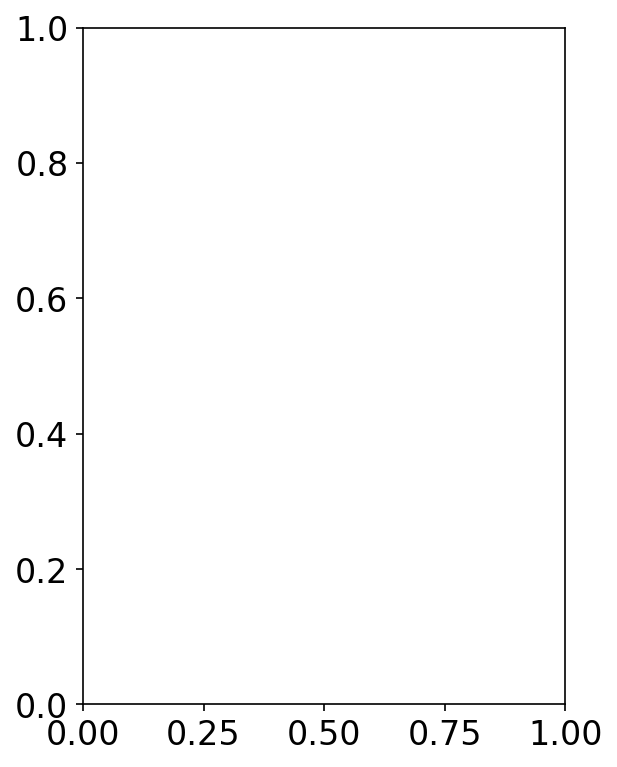

In [8]:
# Plot the emissions in the poloidal cross section
from matplotlib.colors import LogNorm
from matplotlib.colors import BoundaryNorm
from matplotlib.ticker import LogFormatter
from matplotlib.cm import inferno
import matplotlib.patches as patches

resolution_R = 120
resolution_z = 220

# geometry limits in the poloidal cross section
POLOIDAL_RMIN = 1
POLOIDAL_RMAX = 2.2
POLOIDAL_ZMIN = -1.2
POLOIDAL_ZMAX = 1

dx = np.round((POLOIDAL_RMAX - POLOIDAL_RMIN) / resolution_R, 2) * 1.05
dy = np.round((POLOIDAL_ZMAX - POLOIDAL_ZMIN) / resolution_z, 2) * 1.05
print(dx, dy)

NUM_OF_BINS = wavelengths.shape[0] - 1

cmap = plt.cm.inferno

for ID in id_list:
    CURRENTDIR = INPUTDIR + ID + "/"
    PLOTDIR = CURRENTDIR + "plots_rt_highres/"
    if not os.path.exists(PLOTDIR):
        os.mkdir(PLOTDIR)
    OUTDIR = CURRENTDIR + "output/"
    print(OUTDIR)

    jorekfilenames = sorted([f.name for f in Path(CURRENTDIR + "input/").iterdir() if (f.is_file() and "raytransfer" in str(f))])
    filenames = sorted([f.name for f in Path(OUTDIR).iterdir() if (f.is_file() and PREFIX in str(f))])
    times_SI = [float(f.removeprefix(PREFIX).removesuffix(".h5")) for f in filenames]
    print(len(filenames), "emission output files found.")
    # len(filenames)
    for k in range(len(filenames)):
        fig, ax = plt.subplots(figsize=(4, 5))
        _, _, emissions, _ = open_voxel_measurements(filenames[k], energy_cutoff=False)
        values = emissions.sum(axis=1)
        norm = LogNorm(vmin=1, vmax=1e8)
        
        for i in range(inverse_voxel_map.shape[0]):
            # Get the indices of the i-th voxel in the grid_centres array
            aa = inverse_voxel_map[i, 0, 0]
            cc = inverse_voxel_map[i, 2, 0]

            # Get the real world coordinates corresponding to the i-th voxel
            xi = np.round(grid_centres[aa, cc, 0], 3)  # To get R coordinate
            yi = np.round(grid_centres[aa, cc, 1], 3)  # To get z coordinate

            val = np.sum(emissions[i, :])
            color = cmap(norm(val))
            rect = patches.Rectangle(
                (xi - dx/2, yi - dy/2),  # bottom-left corner
                dx, dy,
                facecolor=color,
                edgecolor='none'
            )
            ax.add_patch(rect)
        
        for line in gc_d_lines:
            ax.plot(line[0], line[1], lw=.5, c="grey", zorder=50)
        
        ax.set_xlabel("r")
        ax.set_ylabel("z")
        ax.set_facecolor('k')
        ax.set_aspect(1.0)
        plt.xlim(POLOIDAL_RMIN-0.1, POLOIDAL_RMAX+0.1)
        plt.ylim(POLOIDAL_ZMIN-0.1, POLOIDAL_ZMAX+0.1)

        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cbar = plt.colorbar(sm, ax=ax)
        cbar.set_label("Emission density [W/m^3]")
        
        plt.title(str(np.round(times_SI[k] * 1000, 2))+" ms")
        plt.savefig(PLOTDIR + "emissions_" + str(k) + ".png", dpi=150)
        print(k)
        plt.close()